In [1]:
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import StringIO
from pathlib import Path
import logging
import zipfile
import gdown 
import os 
import sys
import openpyxl

In [4]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.model_selection import GridSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_curve, auc, mean_squared_error, mean_absolute_error
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

In [5]:
from scipy import stats

In [6]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha' : 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

pallete_config = {'#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653'}

PALETTE = sns.color_palette(pallete_config)

In [7]:
print(f"Pandas version      : {pd.__version__}")
print(f"Numpy version       : {np.__version__}")
print(f"Seaborn version     : {sns.__version__}")
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)

Pandas version      : 3.0.2
Numpy version       : 2.4.4
Seaborn version     : 0.13.2


In [8]:
base = Path("./content/data")
figs = Path("./content/figs")

data_folders = [
    base,
    base / "processed",
    base / "raw",
    base / "figs",
    base / "figs" / "dengue_temperatura_graph",
    figs / "months" / "4",
    figs / "months" / "8",
    figs / "months" / "12",
    figs / "months" / "16"
]

for path in data_folders:
    path.mkdir(parents=True, exist_ok=True)

In [9]:
FIGURES_PATH = Path("./content/figs/months")
DATA_PATH = Path("./content/data/raw/")
PROCESSED_DATA_PATH = Path("./content/data/processed")

In [10]:
file_id = "1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL"
url = f"https://drive.google.com/uc?id={file_id}"
print(url)
download_path = "dataset.zip"
gdown.download(url, download_path, quiet=False)

https://drive.google.com/uc?id=1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL


Downloading...
From: https://drive.google.com/uc?id=1FGMMv8R3xYxJtHj5yV6N1k5o4RupZbeL
To: C:\Users\loren\ml\dataset.zip
100%|███████████████████████████████████████████████████████████████████████████████| 341k/341k [00:00<00:00, 1.90MB/s]


'dataset.zip'

In [11]:
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("./content/data/raw")

In [12]:
try:
    df = pd.read_excel("./content/data/raw/base_modelagem_dengue_dataset.xlsx")
    
except FileNotFoundError:
    logging.error(f"File not found at {DATA_PATH / 'base_modelagem_dengue_dataset.xlsx'}")
    raise
except Exception as e:
    logging.error(f"An error occurred while reading the Excel file: {e}")
    raise

In [13]:
print(f"Datashet shape: {df.shape[0]}, rows x {df.shape[1]} columns")

Datashet shape: 784, rows x 73 columns


In [14]:
print("=" * 80)
print("Colunas")
print("=" * 80)
for col in df.columns:
    dtype = df[col].dtype
    n_null = df[col].isnull().sum()
    sample = df[col].iloc[0] if len(df) > 0 else 'N/A'
    print(f"  {col:<45} dtype={str(dtype):<10} nulls={n_null:<4} sample={sample}")

Colunas
  dt_pri_sem                                    dtype=datetime64[us] nulls=0    sample=2010-12-26 00:00:00
  ano                                           dtype=int64      nulls=0    sample=2010
  Ano_Seman                                     dtype=int64      nulls=0    sample=201052
  semana_epidemiologica                         dtype=int64      nulls=0    sample=52
  dem                                           dtype=int64      nulls=0    sample=711825
  Trend SP                                      dtype=int64      nulls=0    sample=3
  n dengue                                      dtype=int64      nulls=0    sample=235
  n zika                                        dtype=int64      nulls=0    sample=0
  n chi                                         dtype=int64      nulls=0    sample=0
  N dengue N1N_jar                              dtype=int64      nulls=0    sample=18
  N dengue N1NE_BRO                             dtype=int64      nulls=0    sample=5
  N dengue N1E_SER

In [15]:
date_col = 'dt_pri_sem'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)
df.set_index(date_col, inplace=True)
inferred_freq = pd.infer_freq(df.index)
print(f"Freq: {inferred_freq}")

Freq: W-SUN


In [16]:
targets_datasets = "n dengue"

print(f"Target (casos de dengue): '{targets_datasets}'")
print(f"Mínimo: {df[targets_datasets].min()}")
print(f"Máximo: {df[targets_datasets].max()}")
print(f"Média: {df[targets_datasets].mean():.2f}")
print(f"Desvio Padrão: {df[targets_datasets].std():.2f}")

Target (casos de dengue): 'n dengue'
Mínimo: 6
Máximo: 6013
Média: 476.76
Desvio Padrão: 819.23


In [17]:
colunas_climaticas = [
    'maior_temperatura_semana', 'menor_temperatura_semana', 'media_temperatura_semana',
    'desvio_temperatura_semana', 'amplitude_termica_semana',
    'maior_ponto_orvalho_semana', 'menor_ponto_orvalho_semana',
    'media_ponto_orvalho_semana', 'desvio_ponto_orvalho_semana',
    'maior_umidade_semana', 'menor_umidade_semana', 'media_umidade_semana',
    'desvio_umidade_semana', 'chuva_total_mm',
    'numero_dias_nublados_semana', 'numero_dias_com_chuva_semana',
    'dias_com_tempestade', 'maior_sequencia_dias_consecutivos_chuva'
]

In [18]:
indices_climaticos = ['ONI', 'AMM_SST', 'AMM_WIND', 'AAO_SAM']

In [19]:
colunas_epidemiologicas = ['ONI', 'AMM_SST', 'AMM_WIND', 'AAO_SAM']
colunas_espaciais = [c for c in df.columns if 'N dengue N' in c]
colunas_temporais = ['semana_epidemiologica', 'semana_sin', 'semana_cos',
                 'surto_ano_anterior', 'surto_ano_anterior_norm', 'dengue_ano_passado']

In [20]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("Sem valores NULL. O dataset está completo!")
else:
    print(f"{len(missing)} Colunas com valores faltantes:")
    print(missing.to_string())

Sem valores NULL. O dataset está completo!


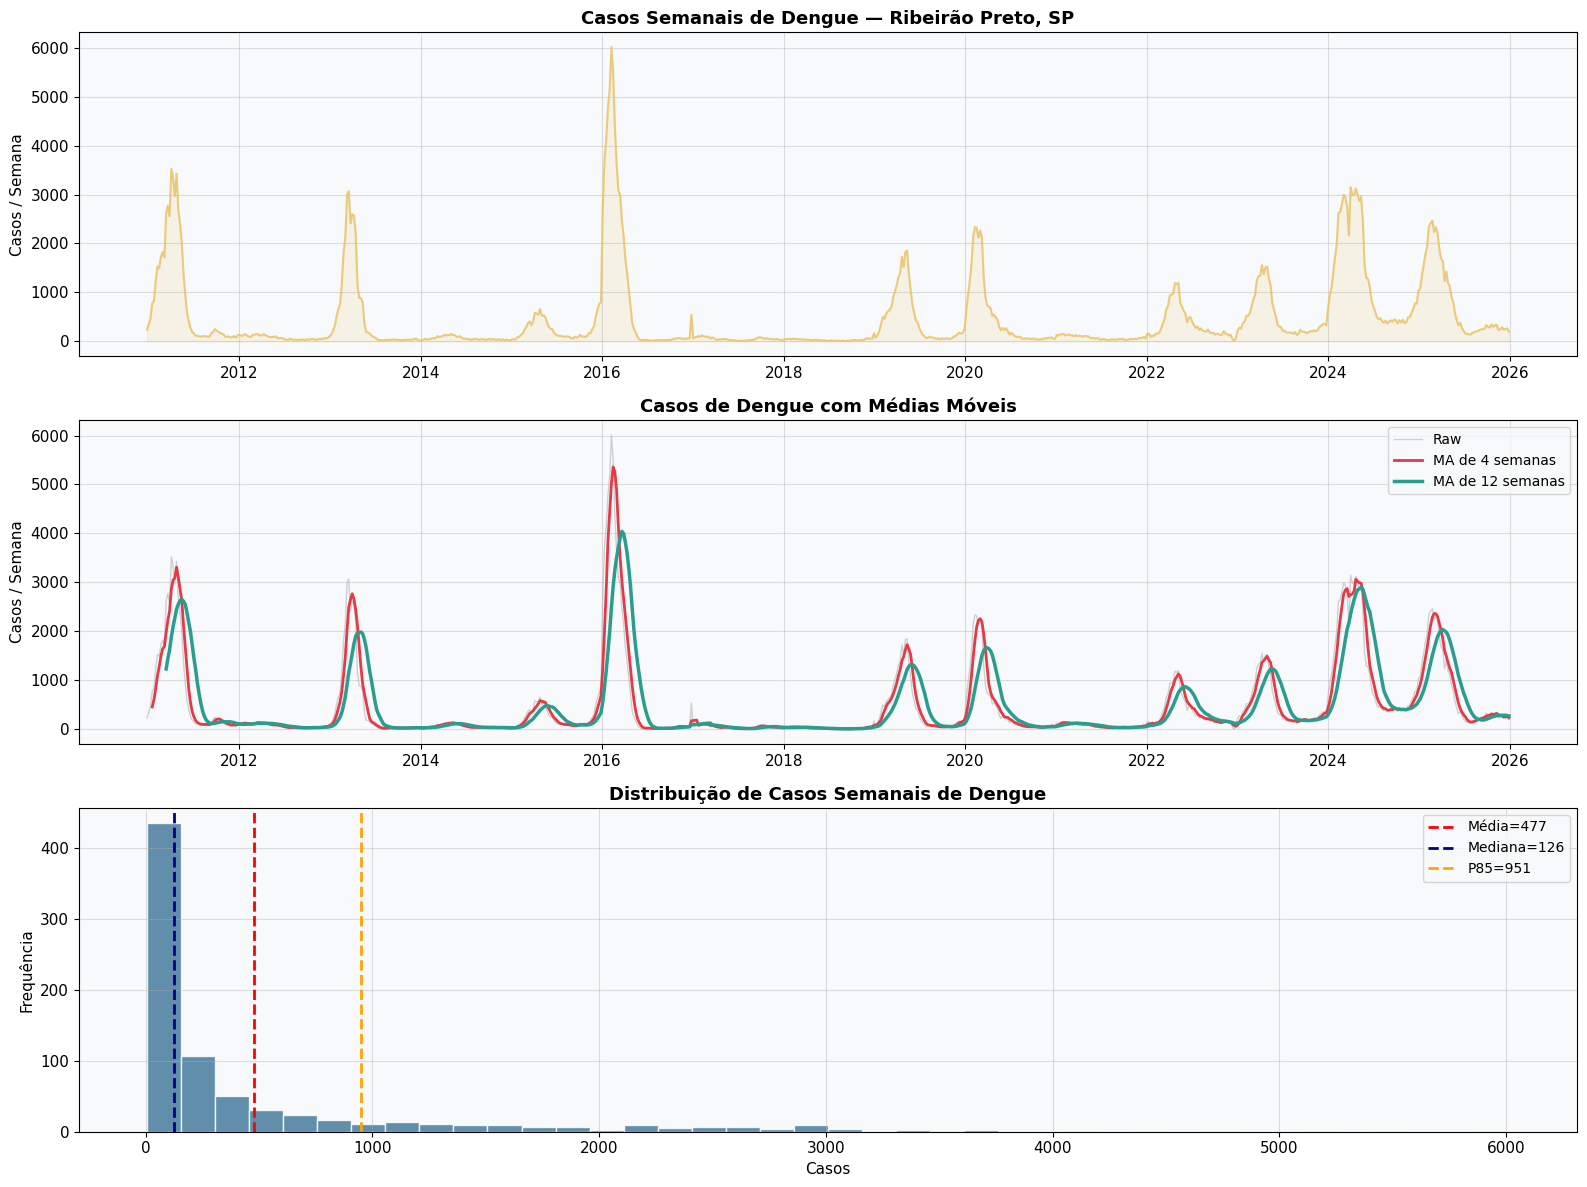

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df.index, df[targets_datasets], color=PALETTE[0], linewidth=1.5, alpha=0.85)
axes[0].fill_between(df.index, 0, df[targets_datasets], color=PALETTE[0], alpha=0.15)
axes[0].set_title('Casos Semanais de Dengue — Ribeirão Preto, SP', fontweight='bold')
axes[0].set_ylabel('Casos / Semana')
axes[0].set_xlabel('')

roll4  = df[targets_datasets].rolling(4).mean()
roll12 = df[targets_datasets].rolling(12).mean()
axes[1].plot(df.index, df[targets_datasets], color='#adb5bd', linewidth=1, label='Raw', alpha=0.6)
axes[1].plot(df.index, roll4,  color=PALETTE[1], linewidth=2,   label='MA de 4 semanas')
axes[1].plot(df.index, roll12, color=PALETTE[2], linewidth=2.5, label='MA de 12 semanas')
axes[1].set_title('Casos de Dengue com Médias Móveis', fontweight='bold')
axes[1].set_ylabel('Casos / Semana')
axes[1].legend()

axes[2].hist(df[targets_datasets], bins=40, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[2].axvline(df[targets_datasets].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Média={df[targets_datasets].mean():.0f}')
axes[2].axvline(df[targets_datasets].median(), color='navy',   linestyle='--', linewidth=2, label=f'Mediana={df[targets_datasets].median():.0f}')
axes[2].axvline(df[targets_datasets].quantile(0.85), color='orange', linestyle='--', linewidth=2, label=f'P85={df[targets_datasets].quantile(0.85):.0f}')
axes[2].set_title('Distribuição de Casos Semanais de Dengue', fontweight='bold')
axes[2].set_xlabel('Casos')
axes[2].set_ylabel('Frequência')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_dengue_series.png', dpi=150, bbox_inches='tight')
plt.show()

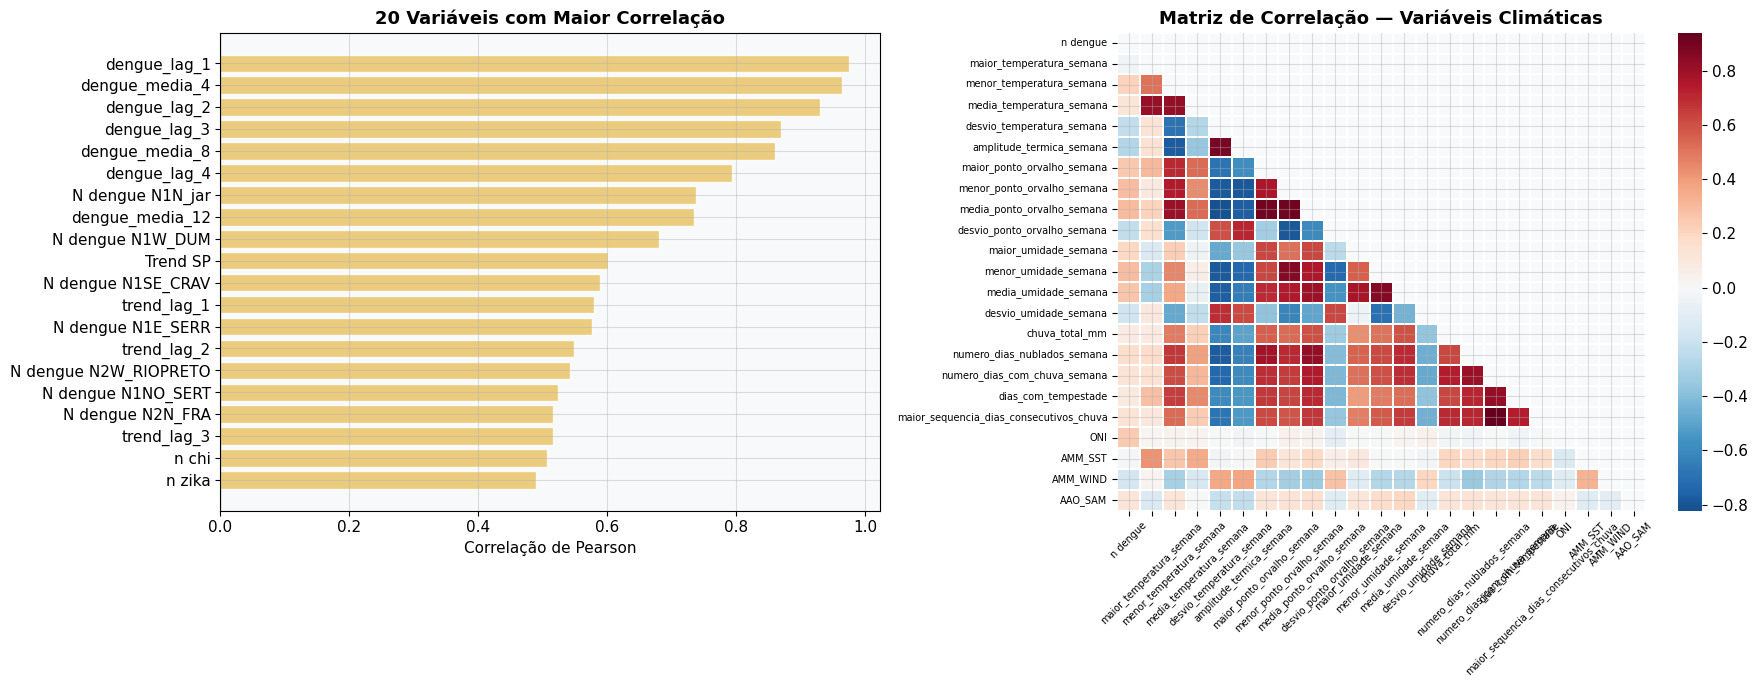

In [22]:
numeric_df = df.select_dtypes(include=[np.number])
corr_with_dengue = numeric_df.corrwith(df[targets_datasets]).drop(targets_datasets, errors='ignore')
corr_with_dengue = corr_with_dengue.dropna().sort_values(key=abs, ascending=False)

top20 = corr_with_dengue.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in top20.values]
axes[0].barh(top20.index, top20.values, color=colors, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('20 Variáveis com Maior Correlação', fontweight='bold')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].invert_yaxis()

heatmap_cols = [targets_datasets] + colunas_climaticas + indices_climaticos
heatmap_cols = [c for c in heatmap_cols if c in numeric_df.columns]
corr_matrix = numeric_df[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], cmap='RdBu_r',
            center=0, annot=False, linewidths=0.3,
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
axes[1].set_title('Matriz de Correlação — Variáveis Climáticas', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

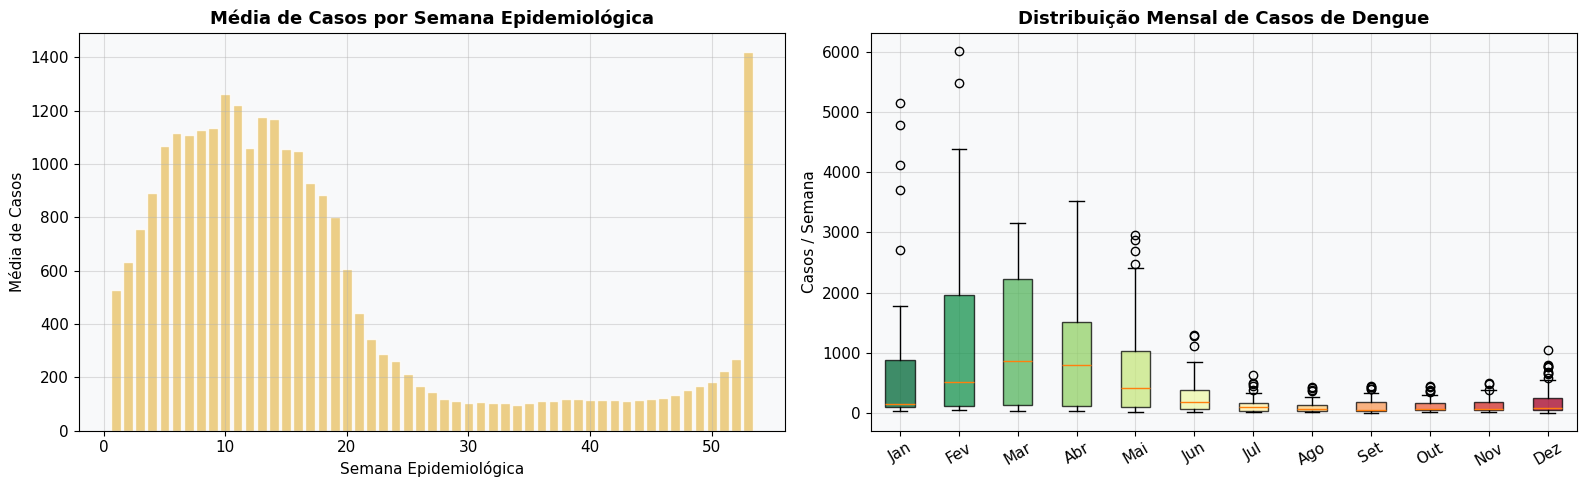

In [23]:
df['week_of_year'] = df.index.isocalendar().week.astype(int)
weekly_avg = df.groupby('week_of_year')[targets_datasets].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(weekly_avg.index, weekly_avg.values, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].set_title('Média de Casos por Semana Epidemiológica', fontweight='bold')
axes[0].set_xlabel('Semana Epidemiológica')
axes[0].set_ylabel('Média de Casos')

df['month'] = df.index.month
month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
monthly_data = [df[df['month'] == m][targets_datasets].values for m in range(1, 13)]
bp = axes[1].boxplot(monthly_data, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], plt.cm.RdYlGn_r(np.linspace(0, 1, 12))):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xticklabels(month_names, rotation=30)
axes[1].set_title('Distribuição Mensal de Casos de Dengue', fontweight='bold')
axes[1].set_ylabel('Casos / Semana')

plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
if df['ano'].nunique() >= 3:
    epi_week_threshold = (
        df.groupby('semana_epidemiologica')[targets_datasets]
          .quantile(0.75)
          .rename('p75_threshold')
    )
    df = df.join(epi_week_threshold, on='semana_epidemiologica')
    df['limite_surto'] = df['p75_threshold']
    method_used = 'Week-specific P75 (Channel Endemic)'
else:
    global_p85 = df[targets_datasets].quantile(0.85)
    df['limite_surto'] = global_p85
    method_used = 'Global P85 (limited data fallback)'

df['acima_limite'] = (df[targets_datasets] > df['limite_surto']).astype(int)

roll3_cases = df[targets_datasets].rolling(3, min_periods=1).mean()
df['surto_persistente'] = (
    (df['acima_limite'] == 1) &
    (roll3_cases > df['limite_surto'] * 1.1)
).astype(int)

HORIZONTE_PREDICAO = 16

df['rotulo_surto'] = df['surto_persistente'].shift(-HORIZONTE_PREDICAO)

valid_df = df.dropna(subset=['rotulo_surto'])
counts = valid_df['rotulo_surto'].value_counts()
total  = len(valid_df)
for cls, cnt in counts.items():
    print(f"   Class {int(cls)} ({'Outbreak' if cls == 1 else 'Normal '}): {cnt:>4} weeks ({cnt/total*100:.1f}%)")


   Class 0 (Normal ):  593 weeks (77.2%)
   Class 1 (Outbreak):  175 weeks (22.8%)


In [25]:
fe = df.copy()

print("A) Criando features de defasagem da dengue...")
for lag in [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 16]:
    fe[f'dengue_lag_{lag}'] = fe[targets_datasets].shift(lag)

print("B) Criando estatísticas móveis...")
for window in [4, 8, 12]:
    fe[f'dengue_roll_mean_{window}'] = fe[targets_datasets].rolling(window).mean()
    fe[f'dengue_roll_std_{window}']  = fe[targets_datasets].rolling(window).std()
    fe[f'dengue_roll_max_{window}']  = fe[targets_datasets].rolling(window).max()
    fe[f'dengue_roll_min_{window}']  = fe[targets_datasets].rolling(window).min()

print("C) Criando features climáticas defasadas...")
climate_base = ['media_temperatura_semana', 'media_umidade_semana',
                'chuva_total_mm', 'media_ponto_orvalho_semana',
                'amplitude_termica_semana']
climate_base = [c for c in climate_base if c in fe.columns]

for col in climate_base:
    for lag in [1, 2, 4, 8]:
        fe[f'{col}_lag{lag}'] = fe[col].shift(lag)
    fe[f'{col}_roll4_mean'] = fe[col].rolling(4).mean()
    fe[f'{col}_roll8_mean'] = fe[col].rolling(8).mean()

print("D) Índices de teleconexão climática (ONI, AMM, AAO)...")
for idx in indices_climaticos:
    if idx in fe.columns:
        for lag in [4, 8, 12]:
            fe[f'{idx}_lag{lag}'] = fe[idx].shift(lag)

print("E) Calculando features de distribuição espacial...")
spatial_cols_avail = [c for c in colunas_espaciais if c in fe.columns]
if spatial_cols_avail:
    fe['total_subregions'] = fe[spatial_cols_avail].sum(axis=1).replace(0, np.nan)
    for col in spatial_cols_avail:
        fe[f'{col}_frac'] = fe[col] / fe['total_subregions']
    fe['spatial_entropy'] = -(
        fe[[f'{c}_frac' for c in spatial_cols_avail]]
        .clip(lower=1e-9)
        .apply(lambda x: x * np.log(x), axis=1)
        .sum(axis=1)
    )
    fe['spatial_concentration'] = fe[spatial_cols_avail].max(axis=1) / fe['total_subregions'].replace(0, np.nan)

print("F) Features de calendário / sazonalidade...")
fe['week_sin'] = np.sin(2 * np.pi * fe['week_of_year'] / 52)
fe['week_cos'] = np.cos(2 * np.pi * fe['week_of_year'] / 52)

print("G) Criando features de taxa de variação...")
fe['dengue_pct_change_1w'] = fe[targets_datasets].pct_change(1)
fe['dengue_pct_change_4w'] = fe[targets_datasets].pct_change(4)
fe['dengue_velocity'] = fe[targets_datasets].diff(1)
fe['dengue_acceleration'] = fe['dengue_velocity'].diff(1)

if 'predominancia_direcao_vento_semana' in fe.columns:
    fe = pd.get_dummies(
        fe,
        columns=['predominancia_direcao_vento_semana'],
        prefix='wind',
        drop_first=False
    )

fe['dengue_52w_lag'] = fe[targets_datasets].shift(52)
print("Concluido!")

A) Criando features de defasagem da dengue...
B) Criando estatísticas móveis...
C) Criando features climáticas defasadas...
D) Índices de teleconexão climática (ONI, AMM, AAO)...
E) Calculando features de distribuição espacial...
F) Features de calendário / sazonalidade...
G) Criando features de taxa de variação...
Concluido!


In [27]:
PREDICTION_HORIZON = 16

df['rotulo_surto'] = df['surto_persistente'].shift(-PREDICTION_HORIZON)

LABEL_COL = 'rotulo_surto'

fe_clean = fe.dropna(subset=[LABEL_COL]).copy()

EXCLUDE = [
    targets_datasets, 'n zika', 'n chi', LABEL_COL,
    'limite_surto', 'acima_limite', 'surto_persistente',
    'ano', 'Ano_Seman', 'linha_original', 'week_of_year', 'month',
    'dengue_ano_passado',
    'surto_ano_anterior_norm', 'surto_ano_anterior',
    'p75_threshold',
    'Trend SP',
]

feature_cols = [
    c for c in fe_clean.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE and not c.startswith('N dengue N')
]

fe_clean[feature_cols] = (
    fe_clean[feature_cols]
    .ffill()
    .bfill()
    .fillna(0)
)

X = fe_clean[feature_cols]
y = fe_clean[LABEL_COL].astype(int)

split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()

X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

In [28]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, cw))

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

In [29]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_cv.fit(X_train, y_train)

rf_best = rf_cv.best_estimator_

y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\loren\notebooks-ml\venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


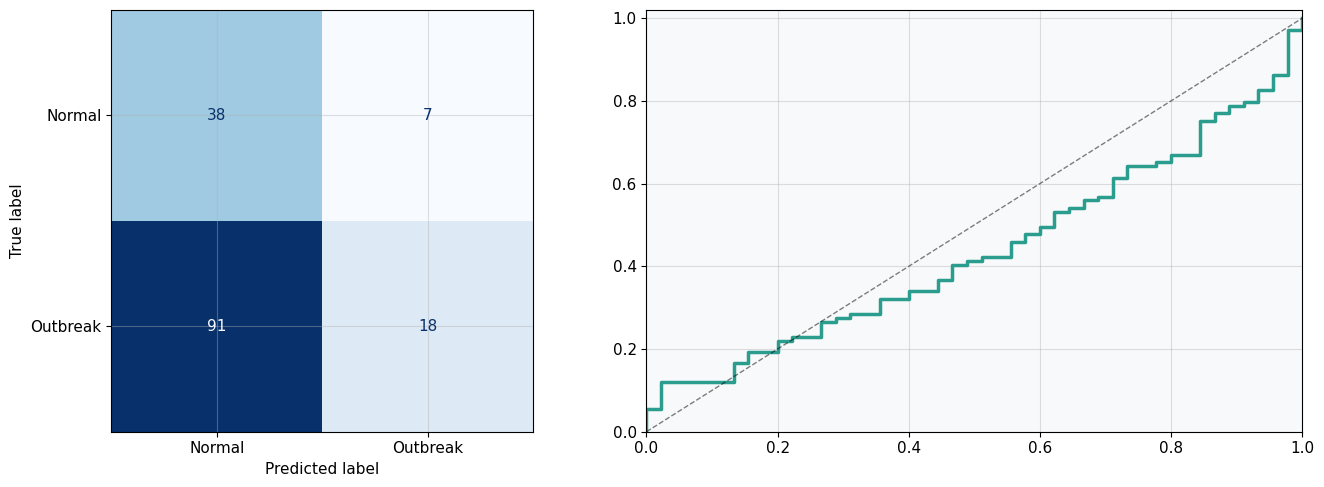

In [30]:
def evaluate_classifier(y_true, y_pred, y_prob, model_name='Model'):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = float('nan')

    return {
        'acurácia': acc,
        'precisão': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc,
        'modelo': model_name
    }

rf_metrics = evaluate_classifier(
    y_test,
    y_pred_rf,
    y_prob_rf,
    'Random Forest (Optimized)'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=['Normal', 'Outbreak']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')

if not np.isnan(rf_metrics['roc_auc']):
    fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
    axes[1].plot(
        fpr,
        tpr,
        color=PALETTE[0],
        linewidth=2.5,
        label=f"RF (AUC = {rf_metrics['roc_auc']:.3f})"
    )

axes[1].plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1,
    alpha=0.5
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('rf_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

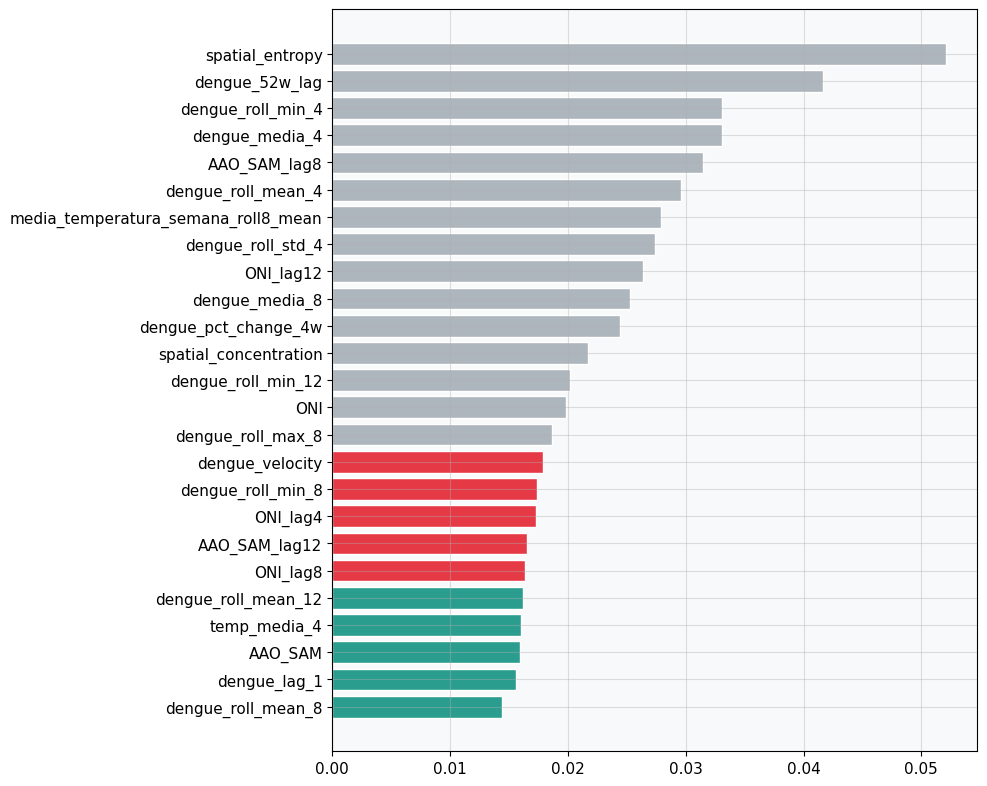

In [31]:
importances = pd.Series(
    rf_best.feature_importances_,
    index=feature_cols
)

importances = (
    importances
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 8))

colors_imp = [
    PALETTE[0] if i < 5 else PALETTE[1] if i < 10 else '#adb5bd'
    for i in range(len(importances))
]

ax.barh(
    importances.index,
    importances.values,
    color=colors_imp[::-1],
    edgecolor='white'
)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    'rf_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

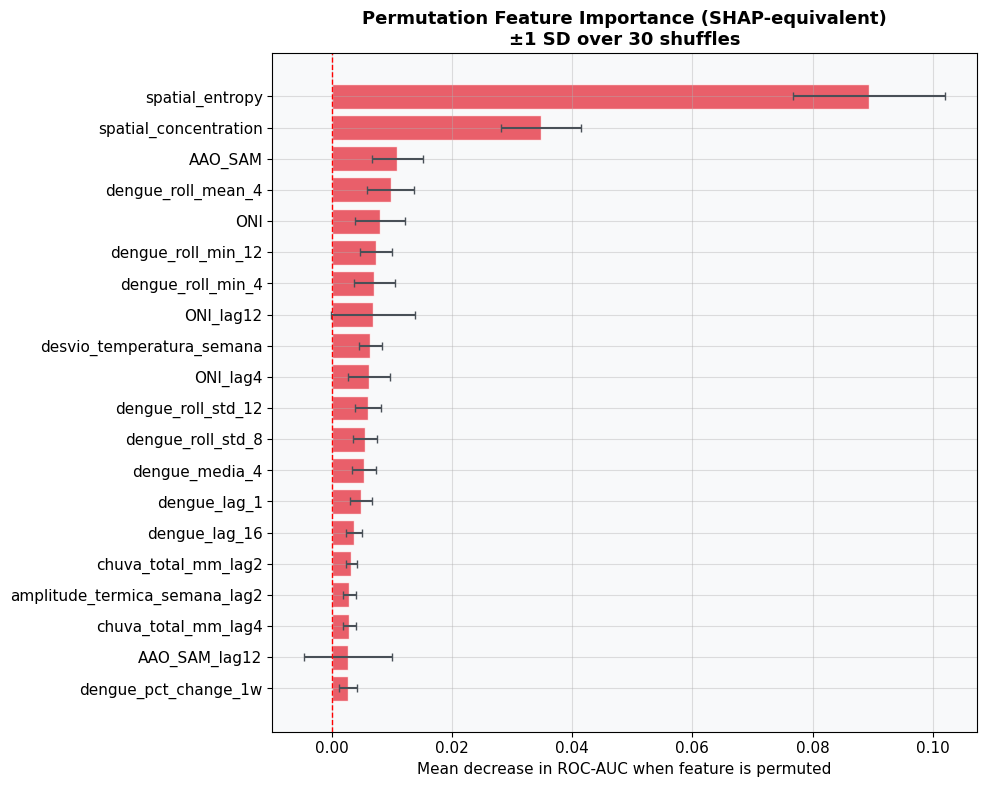

In [32]:
perm_imp = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : perm_imp.importances_mean,
    'std'        : perm_imp.importances_std
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=PALETTE[1], alpha=0.8,
        edgecolor='white', ecolor='#495057', capsize=3)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Permutation Feature Importance (SHAP-equivalent)\n±1 SD over 30 shuffles', fontweight='bold')
ax.set_xlabel('Mean decrease in ROC-AUC when feature is permuted')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\loren\notebooks-ml\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\loren\notebooks-ml\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\loren\notebooks-ml\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\loren\notebooks-ml\venv\Lib\site-packages\sklearn\utils\parallel.py

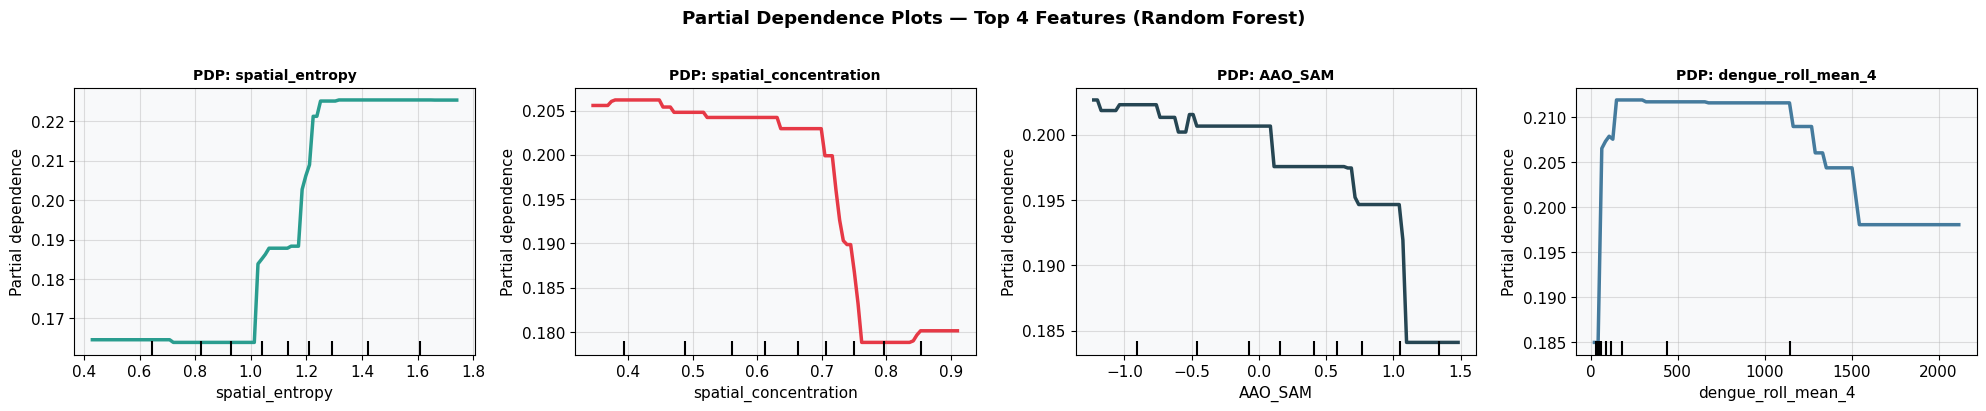

In [33]:
from sklearn.inspection import PartialDependenceDisplay

top4_features = perm_df['feature'].head(4).tolist()
top4_features = [f for f in top4_features if f in feature_cols][:4]

if top4_features:
    fig, axes = plt.subplots(1, len(top4_features), figsize=(5*len(top4_features), 4))
    if len(top4_features) == 1:
        axes = [axes]

    for i, feat in enumerate(top4_features):
        feat_idx = feature_cols.index(feat)
        disp = PartialDependenceDisplay.from_estimator(
            rf_best, X_train, [feat_idx],
            ax=axes[i], kind='average',
            line_kw={'color': PALETTE[i % len(PALETTE)], 'linewidth': 2.5}
        )
        axes[i].set_title(f'PDP: {feat}', fontweight='bold', fontsize=10)
        axes[i].set_xlabel(feat, fontsize=8)
        axes[i].set_ylabel('Predicted Outbreak Prob.', fontsize=8)

    plt.suptitle('Partial Dependence Plots — Top 4 Features (Random Forest)', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('partial_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()


In [34]:
class LSTMCell:
    def __init__(self, input_size, hidden_size, seed=42):
        rng = np.random.default_rng(seed)

        scale_i = np.sqrt(2.0 / (input_size + hidden_size))
        scale_h = np.sqrt(2.0 / (hidden_size + hidden_size))

        self.Wf = rng.normal(0, scale_i, (hidden_size, input_size))
        self.Uf = rng.normal(0, scale_h, (hidden_size, hidden_size))
        self.bf = np.zeros((hidden_size, 1))

        self.Wi = rng.normal(0, scale_i, (hidden_size, input_size))
        self.Ui = rng.normal(0, scale_h, (hidden_size, hidden_size))
        self.bi = np.zeros((hidden_size, 1))

        self.Wg = rng.normal(0, scale_i, (hidden_size, input_size))
        self.Ug = rng.normal(0, scale_h, (hidden_size, hidden_size))
        self.bg = np.zeros((hidden_size, 1))

        self.Wo = rng.normal(0, scale_i, (hidden_size, input_size))
        self.Uo = rng.normal(0, scale_h, (hidden_size, hidden_size))
        self.bo = np.zeros((hidden_size, 1))

        self.Wy = rng.normal(
            0,
            np.sqrt(2.0 / hidden_size),
            (1, hidden_size)
        )

        self.by = np.zeros((1, 1))

        self.hidden_size = hidden_size
        self.input_size = input_size

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    @staticmethod
    def tanh(x):
        return np.tanh(np.clip(x, -500, 500))

    def forward_sequence(self, X_seq):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))

        for t in range(len(X_seq)):
            x = X_seq[t].reshape(-1, 1)

            f = self.sigmoid(self.Wf @ x + self.Uf @ h + self.bf)
            i = self.sigmoid(self.Wi @ x + self.Ui @ h + self.bi)
            g = self.tanh(self.Wg @ x + self.Ug @ h + self.bg)
            o = self.sigmoid(self.Wo @ x + self.Uo @ h + self.bo)

            c = f * c + i * g
            h = o * self.tanh(c)

        y = self.sigmoid(self.Wy @ h + self.by)

        return y.item(), h, c

    def predict_batch(self, X_sequences):
        preds = []

        for seq in X_sequences:
            prob, _, _ = self.forward_sequence(seq)
            preds.append(prob)

        return np.array(preds)

In [35]:
top_lstm_features_candidates = perm_df['feature'].head(10).tolist()

core_climate = [
    'media_temperatura_semana',
    'chuva_total_mm',
    'media_umidade_semana',
    'ONI',
    'semana_sin',
    'semana_cos'
]

lstm_features = list(
    dict.fromkeys(
        top_lstm_features_candidates +
        [f for f in core_climate if f in feature_cols]
    )
)

lstm_features = [
    f for f in lstm_features
    if f in feature_cols
][:15]

lstm_scaler = MinMaxScaler()

X_lstm_all = (
    fe_clean[lstm_features]
    .ffill()
    .bfill()
    .fillna(0)
)

X_lstm_all_sc = lstm_scaler.fit_transform(X_lstm_all)

y_lstm_all = fe_clean[LABEL_COL].astype(int).values

SEQ_LEN = 12

def build_sequences(X_arr, y_arr, seq_len):
    Xs = []
    ys = []

    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = build_sequences(
    X_lstm_all_sc,
    y_lstm_all,
    SEQ_LEN
)

split_seq = int(len(X_seq) * 0.80)

X_seq_train = X_seq[:split_seq]
X_seq_test = X_seq[split_seq:]

y_seq_train = y_seq[:split_seq]
y_seq_test = y_seq[split_seq:]

In [36]:
def binary_cross_entropy(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

N_FEATURES = len(lstm_features)
HIDDEN_SIZE = 32

lstm = LSTMCell(
    input_size=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    seed=42
)

EPOCHS = 50
BATCH_SIZE = 16
LR = 0.01
EPS_GRAD = 1e-5

train_losses = []
val_losses = []

n_outbreak = y_seq_train.sum()
n_normal = len(y_seq_train) - n_outbreak

pos_weight = n_normal / max(n_outbreak, 1)

sample_wts = np.where(
    y_seq_train == 1,
    pos_weight,
    1.0
)

sample_wts /= sample_wts.sum()

def get_all_weights(model):
    return [
        model.Wf, model.Uf, model.bf,
        model.Wi, model.Ui, model.bi,
        model.Wg, model.Ug, model.bg,
        model.Wo, model.Uo, model.bo,
        model.Wy, model.by
    ]

def set_weight_val(model, wlist, i, j, k, val):
    wlist[i][j, k] = val

def numerical_grad_single(
    model,
    seq,
    y_true,
    weight_list,
    w_idx,
    i,
    j,
    eps=EPS_GRAD
):
    orig = weight_list[w_idx][i, j]

    weight_list[w_idx][i, j] = orig + eps
    yp_plus, _, _ = model.forward_sequence(seq)

    loss_plus = -(
        y_true * np.log(max(yp_plus, 1e-9)) +
        (1 - y_true) * np.log(max(1 - yp_plus, 1e-9))
    )

    weight_list[w_idx][i, j] = orig - eps
    yp_minus, _, _ = model.forward_sequence(seq)

    loss_minus = -(
        y_true * np.log(max(yp_minus, 1e-9)) +
        (1 - y_true) * np.log(max(1 - yp_minus, 1e-9))
    )

    weight_list[w_idx][i, j] = orig

    return (loss_plus - loss_minus) / (2 * eps)

rng = np.random.default_rng(42)

for epoch in range(EPOCHS):
    idx = rng.choice(
        len(X_seq_train),
        size=len(X_seq_train),
        replace=False,
        p=sample_wts
    )

    epoch_loss = 0.0

    for b_start in range(0, len(idx), BATCH_SIZE):
        batch_idx = idx[b_start:b_start + BATCH_SIZE]

        grad_Wy = np.zeros_like(lstm.Wy)
        grad_by = np.zeros_like(lstm.by)

        batch_loss = 0.0

        for bi in batch_idx:
            seq = X_seq_train[bi]
            y_true = float(y_seq_train[bi])

            y_pred, h, c = lstm.forward_sequence(seq)
            y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)

            loss = -(
                y_true * np.log(y_pred) +
                (1 - y_true) * np.log(1 - y_pred)
            )

            batch_loss += loss

            dL_dy = -(
                y_true / y_pred -
                (1 - y_true) / (1 - y_pred)
            )

            dlogit = dL_dy * y_pred * (1 - y_pred)

            grad_Wy += dlogit * h.T
            grad_by += dlogit

        n_batch = max(len(batch_idx), 1)

        lstm.Wy -= LR * grad_Wy / n_batch
        lstm.by -= LR * grad_by / n_batch

        epoch_loss += batch_loss / n_batch

    val_preds = lstm.predict_batch(X_seq_test)
    val_loss = binary_cross_entropy(y_seq_test, val_preds)

    train_losses.append(
        float(epoch_loss) /
        max(len(X_seq_train) // BATCH_SIZE, 1)
    )

    val_losses.append(float(val_loss))

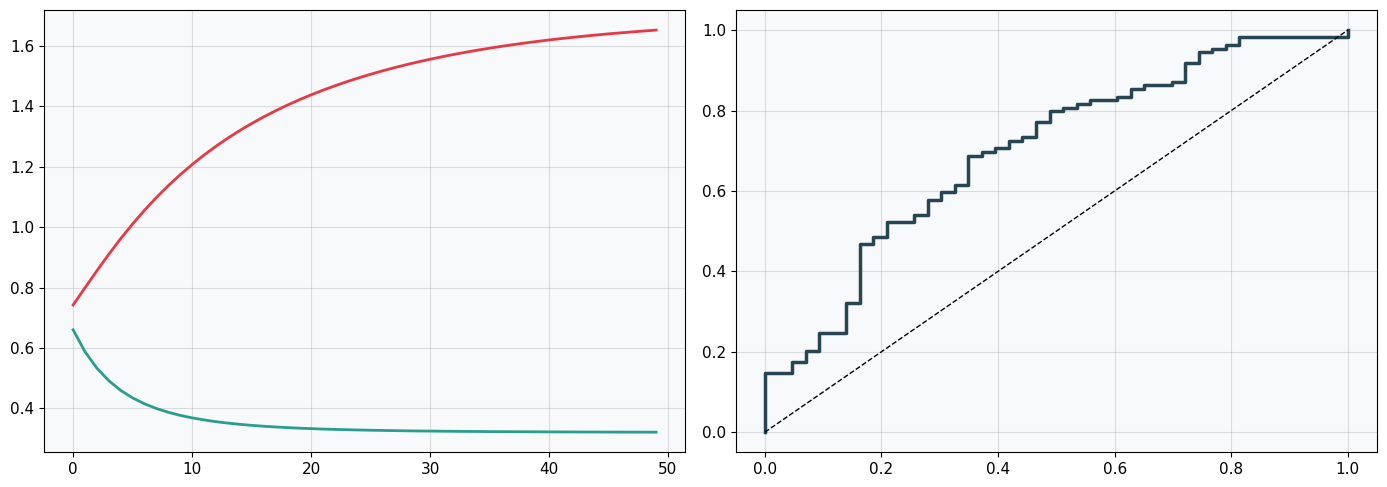

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    train_losses,
    color=PALETTE[0],
    linewidth=2,
    label='Train Loss'
)

axes[0].plot(
    val_losses,
    color=PALETTE[1],
    linewidth=2,
    label='Val Loss'
)

y_prob_lstm = lstm.predict_batch(X_seq_test)

if len(np.unique(y_seq_test)) > 1:
    fpr_l, tpr_l, thresholds_l = roc_curve(
        y_seq_test,
        y_prob_lstm
    )

    J = tpr_l - fpr_l
    best_threshold = thresholds_l[np.argmax(J)]
else:
    best_threshold = 0.5

y_pred_lstm = (
    y_prob_lstm >= best_threshold
).astype(int)

if len(np.unique(y_seq_test)) > 1:
    fpr_l, tpr_l, _ = roc_curve(
        y_seq_test,
        y_prob_lstm
    )

    roc_lstm = roc_auc_score(
        y_seq_test,
        y_prob_lstm
    )

    axes[1].plot(
        fpr_l,
        tpr_l,
        color=PALETTE[2],
        linewidth=2.5,
        label=f"LSTM (AUC = {roc_lstm:.3f})"
    )

    axes[1].plot(
        [0, 1],
        [0, 1],
        'k--',
        linewidth=1
    )
else:
    axes[1].text(
        0.5,
        0.5,
        'Insufficient class\nvariety in test set',
        ha='center',
        va='center',
        transform=axes[1].transAxes
    )

    roc_lstm = float('nan')

plt.tight_layout()

plt.savefig(
    'lstm_evaluation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

lstm_metrics = evaluate_classifier(
    y_seq_test,
    y_pred_lstm,
    y_prob_lstm,
    'LSTM (NumPy)'
)

lstm_metrics['roc_auc'] = roc_lstm

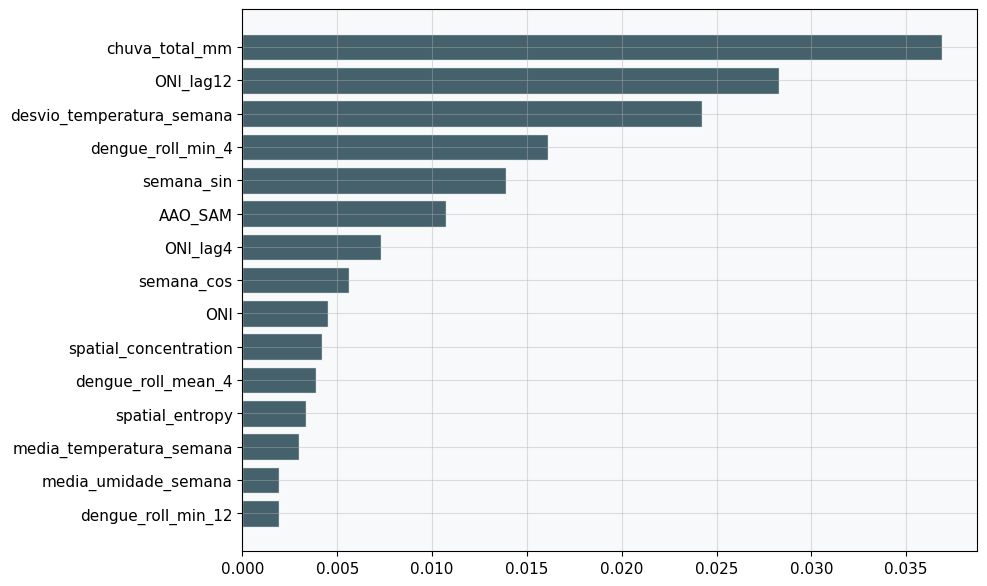

In [38]:
def lstm_feature_sensitivity(model, X_sequences, eps=0.1):
    n_samples, seq_len, n_feat = X_sequences.shape
    sensitivities = np.zeros(n_feat)

    base_preds = model.predict_batch(X_sequences)

    for feat_idx in range(n_feat):
        perturbed = X_sequences.copy()
        perturbed[:, :, feat_idx] += eps

        perturbed_preds = model.predict_batch(perturbed)

        sensitivities[feat_idx] = (
            np.mean(
                np.abs(perturbed_preds - base_preds)
            ) / eps
        )

    return sensitivities

sensitivities = lstm_feature_sensitivity(
    lstm,
    X_seq_test,
    eps=0.1
)

sens_df = pd.DataFrame({
    'feature': lstm_features,
    'sensitivity': sensitivities
}).sort_values(
    'sensitivity',
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    sens_df['feature'],
    sens_df['sensitivity'],
    color=PALETTE[2],
    alpha=0.85,
    edgecolor='white'
)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    'lstm_sensitivity.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

C:\Users\loren\AppData\Local\Temp\ipykernel_7456\256298173.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fe_clean['dengue_future'] = fe_clean[targets_datasets].shift(-PREDICTION_HORIZON)


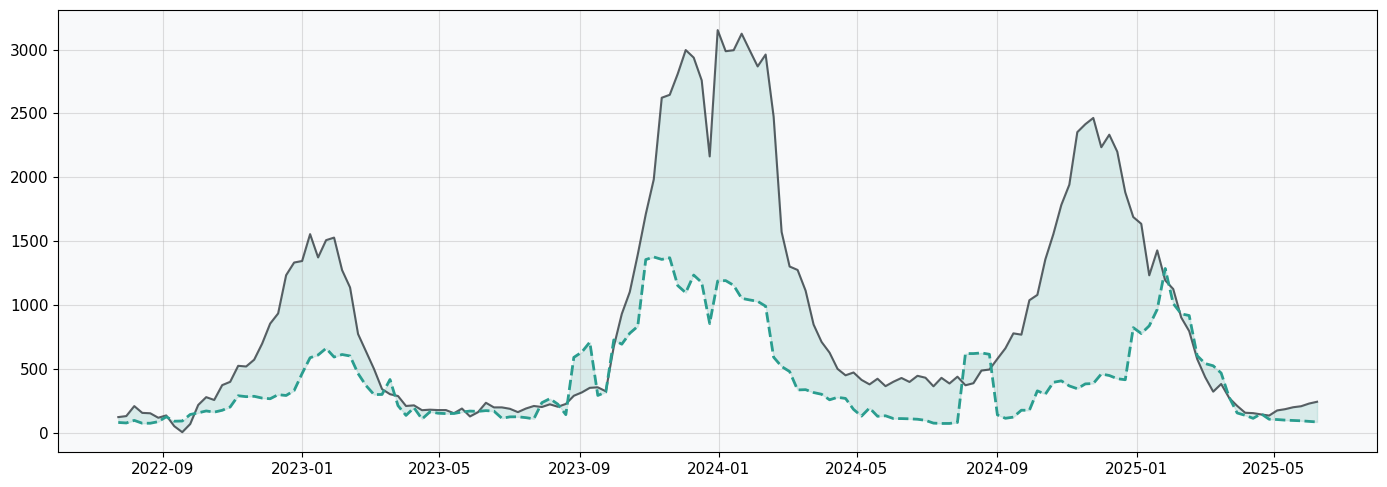

In [39]:
from sklearn.ensemble import RandomForestRegressor

fe_clean['dengue_future'] = fe_clean[targets_datasets].shift(-PREDICTION_HORIZON)

reg_clean = fe_clean.dropna(
    subset=['dengue_future']
).copy()

X_reg = (
    reg_clean[feature_cols]
    .ffill()
    .bfill()
    .fillna(0)
)

y_reg = reg_clean['dengue_future'].values

split_reg = int(len(X_reg) * 0.80)

X_reg_tr = X_reg.iloc[:split_reg]
X_reg_te = X_reg.iloc[split_reg:]

y_reg_tr = y_reg[:split_reg]
y_reg_te = y_reg[split_reg:]

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_reg_tr, y_reg_tr)

y_reg_pred = rf_reg.predict(X_reg_te)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_te,
        y_reg_pred
    )
)

mae = mean_absolute_error(
    y_reg_te,
    y_reg_pred
)

r2 = rf_reg.score(
    X_reg_te,
    y_reg_te
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    reg_clean.index[split_reg:],
    y_reg_te,
    color='#343a40',
    linewidth=1.5,
    alpha=0.8
)

ax.plot(
    reg_clean.index[split_reg:],
    y_reg_pred,
    color=PALETTE[0],
    linewidth=2,
    linestyle='--'
)

ax.fill_between(
    reg_clean.index[split_reg:],
    y_reg_te,
    y_reg_pred,
    alpha=0.15,
    color=PALETTE[0]
)

plt.tight_layout()

plt.savefig(
    'regression_forecast.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

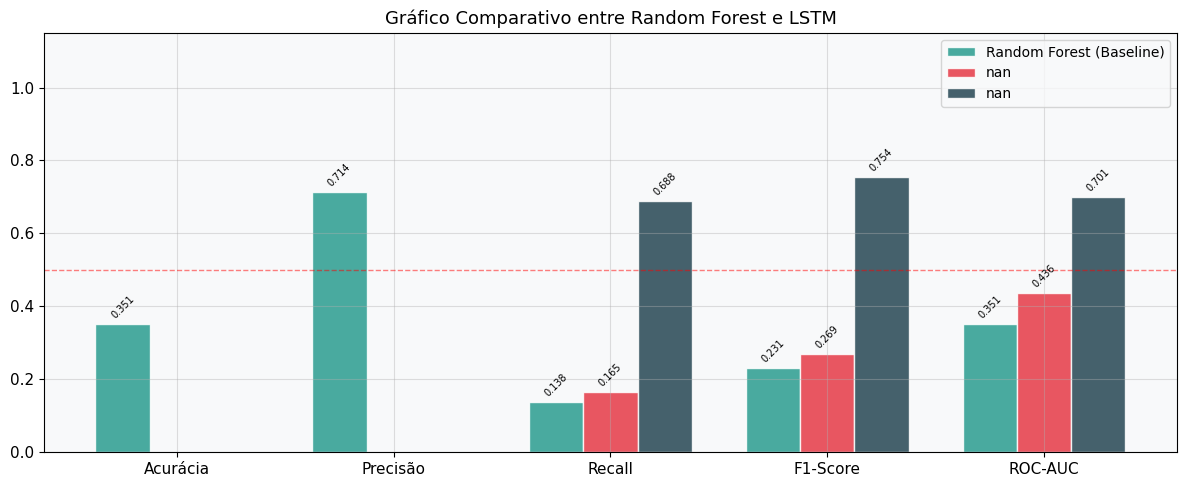

In [40]:
all_metrics = []

base_metrics = {
    'model': 'Random Forest (Baseline)',
    'accuracy': accuracy_score(y_test, y_pred_base),
    'precision': precision_score(y_test, y_pred_base, zero_division=0),
    'recall': recall_score(y_test, y_pred_base, zero_division=0),
    'f1': f1_score(y_test, y_pred_base, zero_division=0),
    'roc_auc': (
        roc_auc_score(y_test, y_prob_base)
        if len(np.unique(y_test)) > 1
        else np.nan
    ),
}

all_metrics.append(base_metrics)
all_metrics.append(rf_metrics)
all_metrics.append(lstm_metrics)

comparison_df = pd.DataFrame(all_metrics).set_index('model')

comparison_df = comparison_df[
    ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
]

comparison_df.columns = [
    'Acurácia',
    'Precisão',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(comparison_df.columns))
width = 0.25

colors_bar = PALETTE[:len(comparison_df)]

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    vals = row.values.astype(float)

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=model_name,
        color=colors_bar[i],
        alpha=0.85,
        edgecolor='white'
    )

    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=7,
                rotation=45
            )

ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df.columns)
ax.set_ylim(0, 1.15)

ax.axhline(
    0.5,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.5
)

plt.title("Gráfico Comparativo entre Random Forest e LSTM")

plt.legend()

plt.tight_layout()

plt.savefig(
    'model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

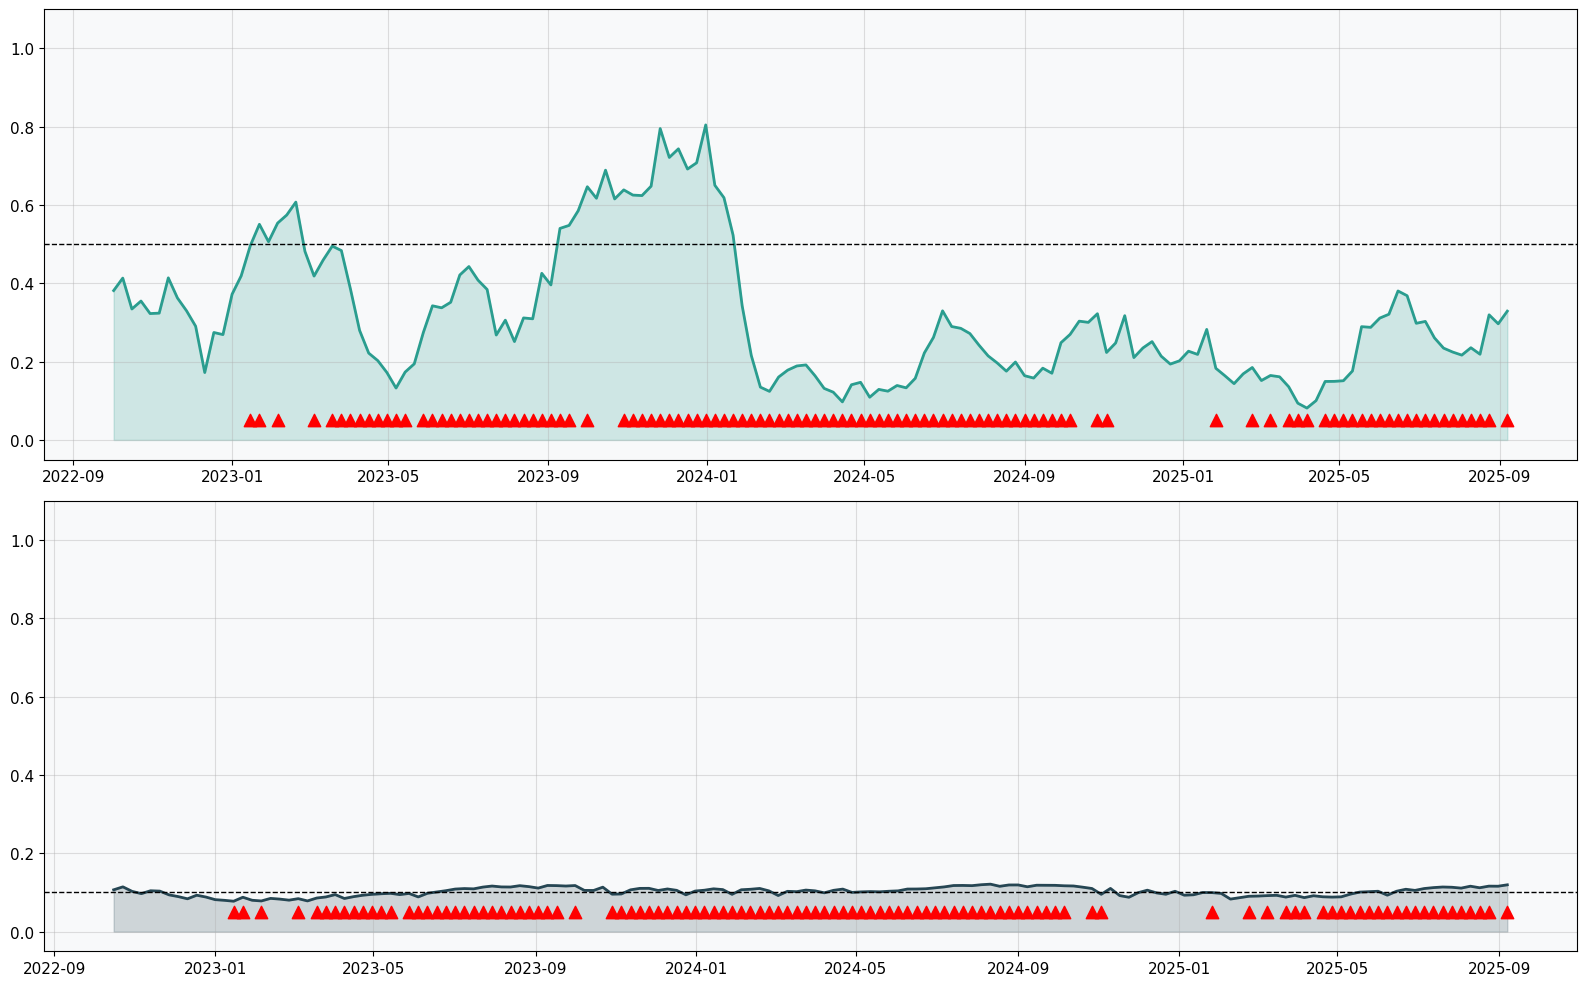

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

ax = axes[0]

test_dates = X_test.index

ax.plot(
    test_dates,
    y_prob_rf,
    color=PALETTE[0],
    linewidth=2
)

ax.fill_between(
    test_dates,
    0,
    y_prob_rf,
    alpha=0.2,
    color=PALETTE[0]
)

ax.axhline(
    0.5,
    color='black',
    linestyle='--',
    linewidth=1
)

outbreak_dates = test_dates[y_test == 1]

if len(outbreak_dates) > 0:
    ax.scatter(
        outbreak_dates,
        [0.05] * len(outbreak_dates),
        marker='^',
        color='red',
        s=80,
        zorder=5
    )

ax.set_ylim(-0.05, 1.1)

ax2 = axes[1]

lstm_test_len = len(y_seq_test)

lstm_test_dates = fe_clean.index[
    SEQ_LEN + split_seq:
    SEQ_LEN + split_seq + lstm_test_len
]

if len(lstm_test_dates) == len(y_prob_lstm):
    ax2.plot(
        lstm_test_dates,
        y_prob_lstm,
        color=PALETTE[2],
        linewidth=2
    )

    ax2.fill_between(
        lstm_test_dates,
        0,
        y_prob_lstm,
        alpha=0.2,
        color=PALETTE[2]
    )

    ax2.axhline(
        best_threshold,
        color='black',
        linestyle='--',
        linewidth=1
    )

    lstm_out_mask = y_seq_test == 1

    if lstm_out_mask.sum() > 0:
        ax2.scatter(
            lstm_test_dates[lstm_out_mask],
            [0.05] * lstm_out_mask.sum(),
            marker='^',
            color='red',
            s=80,
            zorder=5
        )
else:
    ax2.plot(
        y_prob_lstm,
        color=PALETTE[2],
        linewidth=2
    )

    ax2.axhline(
        best_threshold,
        color='black',
        linestyle='--',
        linewidth=1
    )

ax2.set_ylim(-0.05, 1.1)

plt.tight_layout()

plt.savefig(
    'prediction_timeline.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [42]:
print("\nSumário de Métricas Final:")
print("─" * 55)
print(comparison_df.to_string(float_format='{:.4f}'.format))
print("─" * 55)

print("\nSuporte para Regressão:")
print(f"   Random Forest ({PREDICTION_HORIZON}-week case forecast):")
print(f"   RMSE = {rmse:.1f} cases/week")
print(f"   MAE  = {mae:.1f} cases/week")
print(f"   R²   = {r2:.4f}")



Sumário de Métricas Final:
───────────────────────────────────────────────────────
                          Acurácia  Precisão  Recall  F1-Score  ROC-AUC
model                                                                  
Random Forest (Baseline)    0.3506    0.7143  0.1376    0.2308   0.3509
NaN                            NaN       NaN  0.1651    0.2687   0.4363
NaN                            NaN       NaN  0.6881    0.7538   0.7007
───────────────────────────────────────────────────────

Suporte para Regressão:
   Random Forest (13-week case forecast):
   RMSE = 799.9 cases/week
   MAE  = 521.4 cases/week
   R²   = 0.1470
